In [53]:
from rubin_scheduler.site_models import Almanac
import numpy as np

from astropy.coordinates import get_sun, AltAz, EarthLocation

from astropy.time import Time
from rubin_scheduler.utils import Site
import matplotlib.pylab as plt
%matplotlib inline
from scipy.optimize import minimize

In [6]:
alm = Almanac()

In [7]:
np.degrees(alm.sun_moon["sun_alt"])

array([  3.81099384,  -8.84775241, -21.74886577, ..., -41.80134325,
       -37.43514049, -29.83893396], shape=(251907,))

In [15]:
mjds = 65230+np.arange(100)/100.
times = Time(mjds, format="mjd")
site = Site("LSST")
location = EarthLocation(lat=site.latitude, lon=site.longitude, height=site.height)

frame = AltAz(obstime=times, location=location)

#sunaltazs_July12_to_13 = get_sun(times_July12_to_13).transform_to(frame_July12_to_13)

In [16]:
sun_altaz = get_sun(times).transform_to(frame)

/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 100 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 100 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 100 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


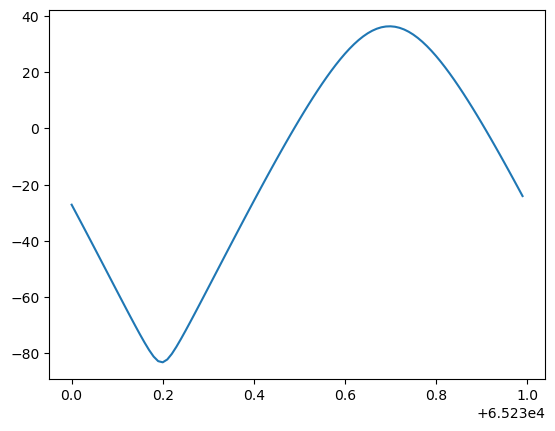

In [22]:
plt.plot(times.mjd, sun_altaz.alt)

In [121]:
class NextTimeSun(object):
    """Find the next time the sun will be at some altitude
    """
    def __init__(self, location=None):
        if location is None:
            site = Site("LSST")
            self.location = EarthLocation(lat=site.latitude, lon=site.longitude, height=site.height)
        else:
            self.location = location
        self.frame = AltAz(location=self.location)

    def _call_to_min(self, mjd):
        return (self.alt_at_mjd(mjd) - self.altitude)**2

    def alt_at_mjd(self, mjd):
        sun_altaz = get_sun(Time(mjd, format="mjd")).transform_to(self.frame)
        return sun_altaz.alt.deg

    def next_mjd_at_alt(self, mjd, altitude=-12.0, rising=True, time_steps=20, length=1.5, **kwargs):
        self.altitude = altitude
        tsteps = np.linspace(0, length, num=time_steps)
        times = Time(mjd +tsteps, format="mjd")
        sun_altaz = get_sun(times).transform_to(self.frame)
        # Get the slopes
        diff_limit = sun_altaz.alt.deg - altitude
        ack = np.diff(np.sign(diff_limit))
        # setting when ack == -2, rising when ack ==2
        # Technically spot on if diff_limit == 0, then ack might be -1 or 1
        if rising:
            indx = np.min(np.where(ack == 2)[0])
        else:
            indx = np.min(np.where(ack == -2)[0])
        x0 = times[indx].mjd 
        delta = time_steps / length
        result = minimize(self._call_to_min, x0, bounds=[(times[indx-1].mjd, times[indx+1].mjd)], **kwargs)
        return result.x
        

        

In [122]:
nts = NextTimeSun()

In [123]:
ack = nts.next_mjd_at_alt(61245)
ack


array([61245.44379384])

In [124]:
nts.alt_at_mjd(ack)

array([-12.00000149])

In [125]:
nts.alt_at_mjd(ack + .1/3600/24)

array([-11.99965553])

In [126]:
nts.next_mjd_at_alt(61245, altitude=-9.)

array([61245.45387356])

In [127]:
nts.next_mjd_at_alt(61245, altitude=-9., rising=False)

array([61245.94845585])

In [128]:
nts.next_mjd_at_alt(61245, altitude=-9., rising=False)

array([61245.94845585])

In [82]:
Time("2026-07-24").mjd

np.float64(61245.0)

In [92]:
np.linspace(0, 1.5, num=20)

array([0.        , 0.07894737, 0.15789474, 0.23684211, 0.31578947,
       0.39473684, 0.47368421, 0.55263158, 0.63157895, 0.71052632,
       0.78947368, 0.86842105, 0.94736842, 1.02631579, 1.10526316,
       1.18421053, 1.26315789, 1.34210526, 1.42105263, 1.5       ])

In [95]:
nts.alt_at_mjd(61245.94845584)

np.float64(-9.000292746535314)

In [94]:
nts.alt_at_mjd(61246.94881498)

np.float64(-8.999996348105956)